In [9]:

import sys

sys.path.append(r"C:\Users\floot\Florian's Laptop\ESILV\CDR\CoupeDeRobotique\common")

from math import cos, sin, radians

from geometry import (
    Point,
    MultiPoint,
    Polygon,
    MultiPolygon,
    LineString,
    BufferCapStyle,
    BufferJoinStyle,
    Geometry,
    create_straight_rectangle,
    prepare,
    distance,

    OrientedPoint,
    nearest_points,
    box
)
from logger import Logger, LogLevels
import numpy as np


from arena import (
    # Enums
    ZoneType,
    ZoneAccessibility,
    # Zones
    BaseArenaZone,
    EnemyZone,
    AllyZone,
    StuffZone,
    BlueReservedZone,
    YellowReservedZone,
    BorderZone,
    ForbiddenZone,
    
    BaseArena,
)


In [10]:
logger_arena = Logger(
    identifier="BaseArena",
    decorator_level=LogLevels.INFO,
    print_log_level=LogLevels.DEBUG,
    file_log_level=LogLevels.DEBUG,
)
logger_grid_manager = Logger(
        identifier="GridManager",
        decorator_level=LogLevels.INFO,
        print_log_level=LogLevels.DEBUG,
        file_log_level=LogLevels.DEBUG,
    )

arena = BaseArena(
    logger_arena,
    width=300,
    height=200,
    border_buffer=2,
    obstacle_buffer=1,
    zones=[],
    chunk_size=5,
    forbidden_cover_threshold=0.1,
    grid_manager_logger=logger_grid_manager,
)

16:03:35.382003 -> [ BaseArena  ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:35.383639 -> [GridManager ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:35.385760 -> [ BaseArena  ]  WARNING   | The border buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
16:03:35.385760 -> [ BaseArena  ]  WARNING   | The obstacle buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
16:03:35.386697 -> [ BorderZone ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:35.552923 -> [GridManager ]   DEBUG    | Function `__mark_zone` executed in 0.160350 seconds.
16:03:35.554076 -> [GridManager ]   DEBUG    | Function `add_forbidden_static_zone` executed in 0.161285 seconds.
16:03:35.555992 -> [  AllyZone  ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:35.557002 

In [11]:
import time
for i in range(10):
    arena.enemy_zone.update("", [], [Point(10+i*3, 10+i)])
    print(arena.enemy_zone)
    time.sleep(0.25)

16:03:35.578452 -> [ BaseArena  ]   DEBUG    | Starting computation of enemy speed vector.
16:03:35.579478 -> [ BaseArena  ]   DEBUG    | Not enough positions recorded to compute speed vector.
ZoneType.FORBIDDEN: POINT (9.999999999999998 10.000000000000002) -> ZoneAccessibility.FORBIDDEN, ally visits: 0, enemy visits: 0, last update: 0.0 Speed: 0, Direction: (0, 0)
16:03:35.844643 -> [ BaseArena  ]   DEBUG    | Enemy visited ZoneType.FORBIDDEN zone
16:03:35.845995 -> [ BaseArena  ]   DEBUG    | Starting computation of enemy speed vector.
16:03:35.847527 -> [ BaseArena  ]   DEBUG    | Start position: POINT (10 10), End position: POINT (13 11).
16:03:35.848548 -> [ BaseArena  ]   DEBUG    | Time delta: 0.26754283905029297 seconds.
16:03:35.850078 -> [ BaseArena  ]   DEBUG    | Displacement vector: dx=3.0, dy=1.0.
16:03:35.851601 -> [ BaseArena  ]   DEBUG    | Distance traveled: 3.1622776601683795.
16:03:35.852640 -> [ BaseArena  ]   DEBUG    | Calculated speed: 11.819705851196158.
16:03:

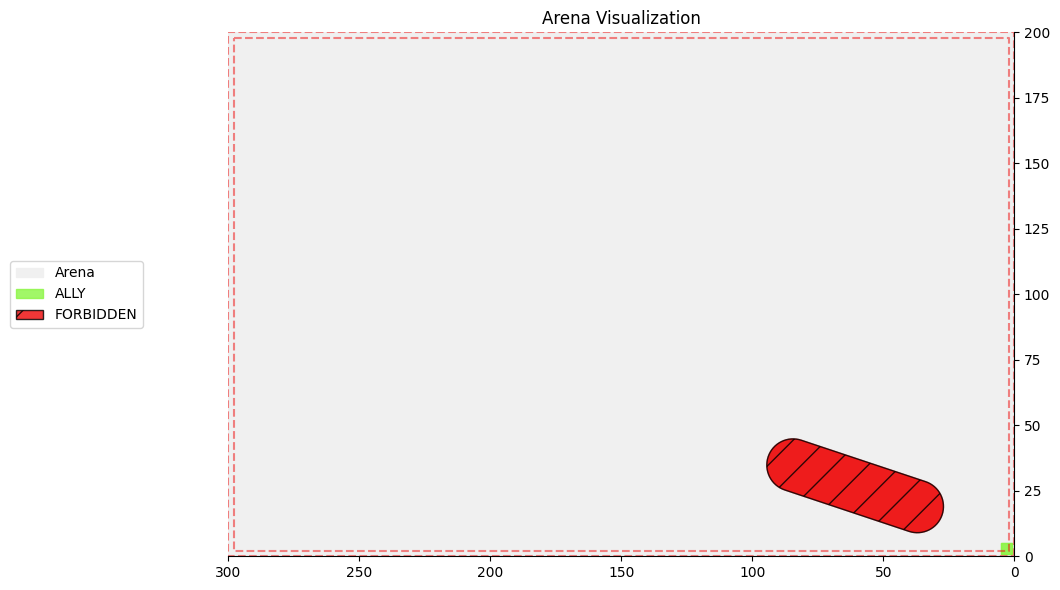

(<Axes: title={'center': 'Arena Visualization'}>,
 <Figure size 1200x600 with 1 Axes>)

In [12]:
arena.visualize()

# Path finding test

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import math
import random
import time

from matplotlib.animation import FuncAnimation
from config_loader import CONFIG

from geometry import (
    Point,
    MultiPoint,
    Polygon,
    MultiPolygon,
    LineString,
    BufferCapStyle,
    BufferJoinStyle,
    Geometry,
    create_straight_rectangle,
    prepare,
    distance,
    OrientedPoint,
    nearest_points,
    box,
)

# Import from common
from logger import Logger, LogLevels
from geometry import OrientedPoint

from arena import (
    ShowArena,
    BaseArenaZone,
    ZoneType,
    EnemyZone,
    StuffZone,
    ForbiddenZone,
    BlueReservedZone,
    YellowReservedZone,
    BorderZone,
)

from pathfinding.core.grid import Grid, GridNode

from path_finding import PathFinder

In [14]:
arena_logger = Logger(
    identifier="NewArena",
    decorator_level=LogLevels.INFO,
    print_log_level=LogLevels.DEBUG,
    file_log_level=LogLevels.DEBUG,
)
finder_logger = Logger(
    identifier="PathFinder",
    decorator_level=LogLevels.INFO,
    print_log_level=LogLevels.DEBUG,
    file_log_level=LogLevels.DEBUG,
)

chunk_size = 5

arena = ShowArena(
    logger=arena_logger,
    border_buffer=2,
    obstacle_buffer=5,
    chunk_size=chunk_size,
)
arena.set_team_color("y")

ally_position = OrientedPoint(25, 15, 0.0)

time.sleep(5)
arena.update(
    ally_position=ally_position,
    lidar_scan_polars=None,
    enemy_position = Point(150, 100), 
)

finder = PathFinder(
    logger=finder_logger,
    start=OrientedPoint(25, 15, 0.0),
    goal=OrientedPoint(275, 120, 0.0),
    grid_manager=arena.grid_manager,
    path_resolution=1,
)

path = finder.find_oriented_path(smooth_path=True)

16:03:38.495816 -> [  NewArena  ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:38.497815 -> [ PathFinder ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:38.498526 -> [ StuffZone  ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:38.501898 -> [YellowRese..]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:38.502990 -> [BlueReserv..]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:38.503535 -> [ForbiddenZ..]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:38.508947 -> [  NewArena  ]  WARNING   | The border buffer is not a multiple of the chunk size -> the not walkable area will not be aligned with the grid
16:03:38.510111 -> [ BorderZone ]    INFO    | Logger initialized, print:   DEBUG   , write to file:   DEBUG   
16:03:38.591162 -> [GridManager ]   DEBUG    | Function 

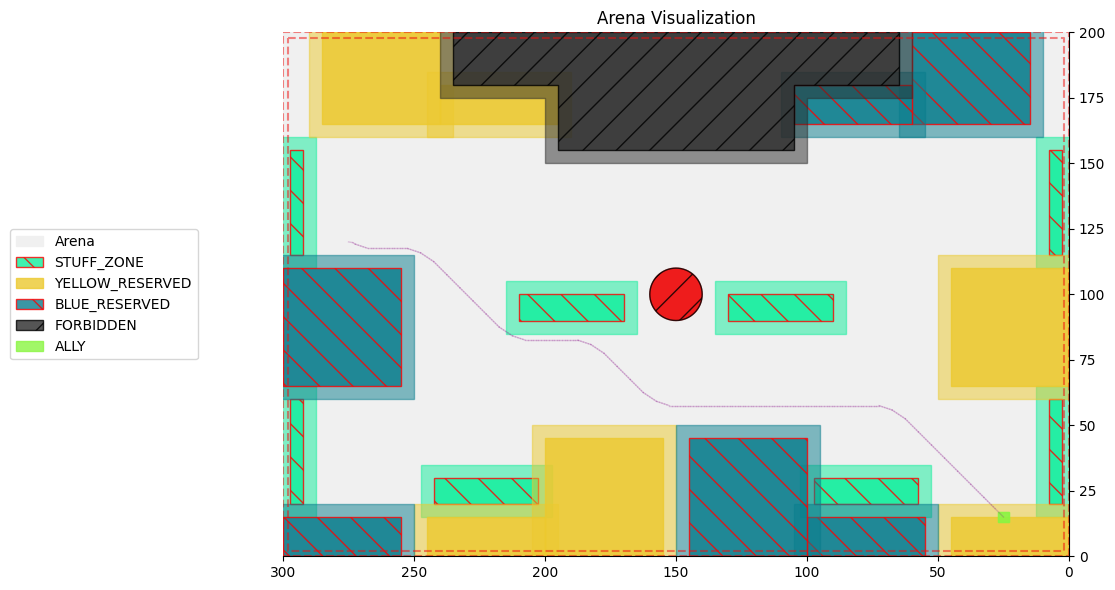

(<Axes: title={'center': 'Arena Visualization'}>,
 <Figure size 1200x600 with 1 Axes>)

In [15]:
arena.visualize(trajectory=path)

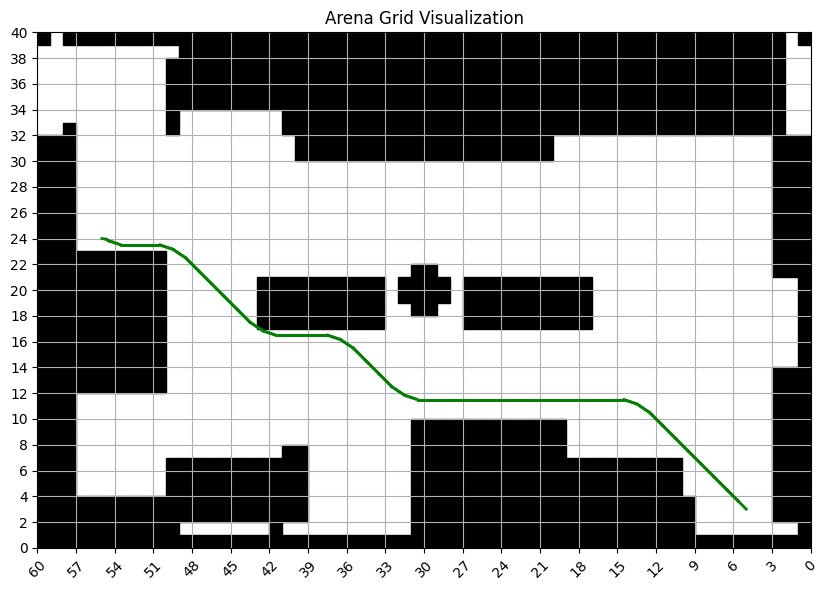

(<Axes: title={'center': 'Arena Grid Visualization'}>,
 <Figure size 1200x600 with 1 Axes>)

In [16]:
arena.grid_manager.visualize(path=[path])